Libraries & initial load

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

# Load dataset
df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Data info & null value analysis

--- Missing values ---
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


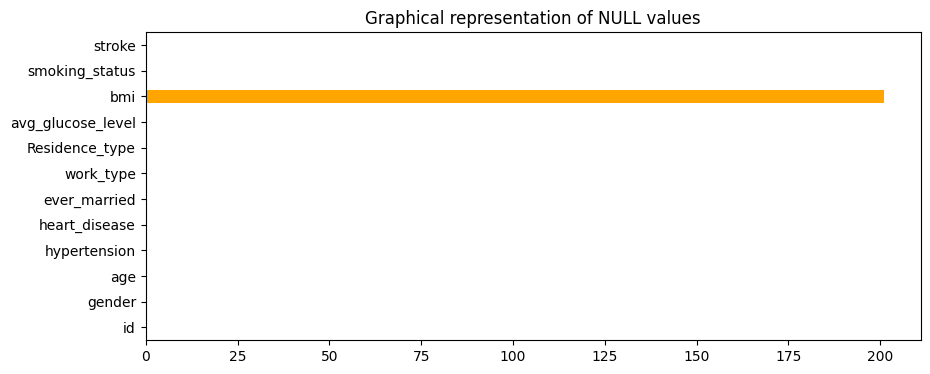

--- Statistical Analysis ---


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [3]:
print("--- Missing values ---")
print(df.isna().sum())

plt.figure(figsize=(10, 4))
df.isna().sum().plot.barh(color='orange')
plt.title("Graphical representation of NULL values")
plt.show()

print("--- Statistical Analysis ---")
display(df.describe())

df.info()

Gender analysis (Univariate)

Gender counts:
 gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


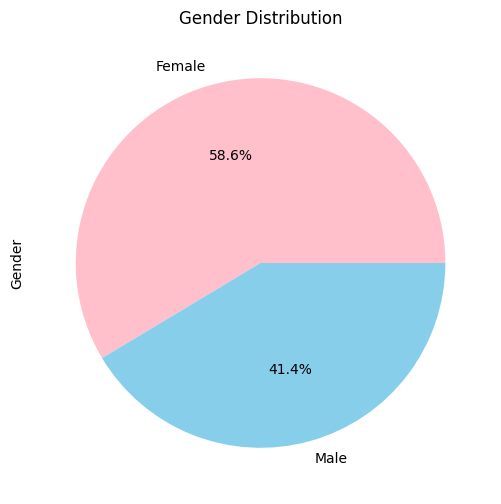

In [4]:
print("Gender counts:\n", df['gender'].value_counts())

df = df[df['gender'] != 'Other']

plt.figure(figsize=(6,6))
df['gender'].value_counts().plot(kind="pie", autopct='%1.1f%%', colors=['pink', 'skyblue'])
plt.ylabel('Gender')
plt.title('Gender Distribution')
plt.show()

Target feature analysis (Stroke)

Stroke counts:
 stroke
0    4860
1     249
Name: count, dtype: int64


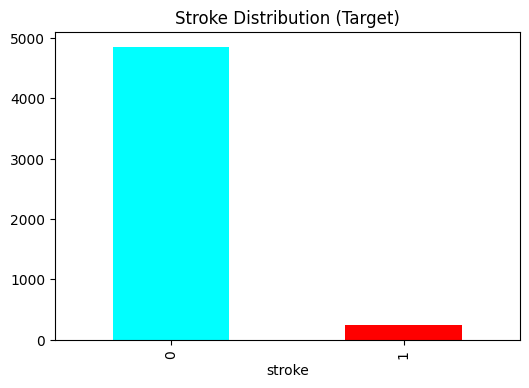

Percentage of people who actually got a stroke: 4.87%


In [5]:
print("Stroke counts:\n", df['stroke'].value_counts())

plt.figure(figsize=(6,4))
df['stroke'].value_counts().plot(kind="bar", color=['cyan', 'red'])
plt.title('Stroke Distribution (Target)')
plt.show()

stroke_perc = (df['stroke'].value_counts()[1] / len(df)) * 100
print(f"Percentage of people who actually got a stroke: {stroke_perc:.2f}%")

BMI & glucose analysis (Outliers & imputation logic)

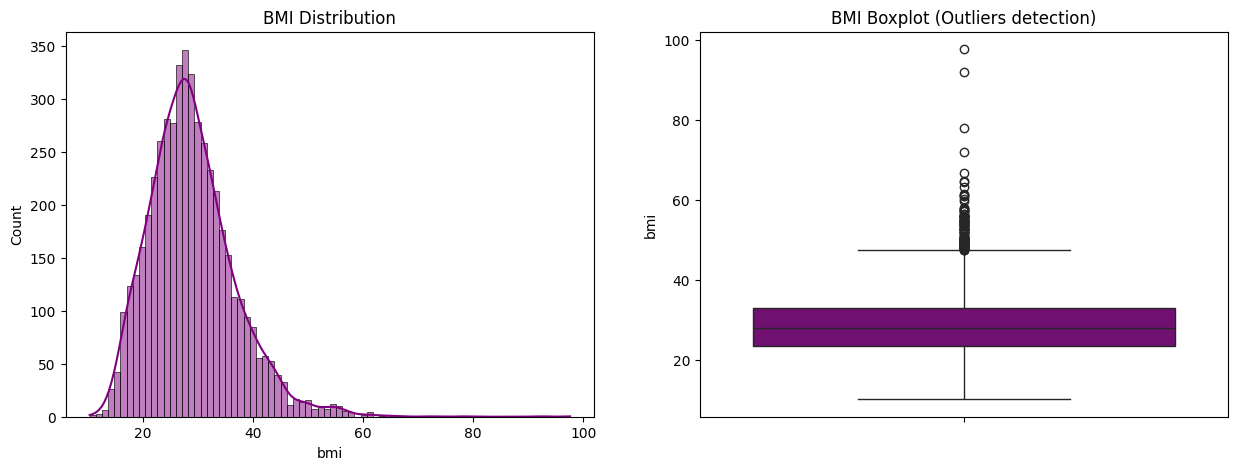

Total outliers in BMI: 110
People who got stroke and their BMI is NA: 40


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['bmi'], kde=True, ax=ax[0], color='purple')
sns.boxplot(data=df['bmi'], ax=ax[1], color='purple')
ax[0].set_title('BMI Distribution')
ax[1].set_title('BMI Boxplot (Outliers detection)')
plt.show()

Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df['bmi'] < (Q1 - 1.5 * IQR)) | (df['bmi'] > (Q3 + 1.5 * IQR))).sum()
print(f"Total outliers in BMI: {outliers}")

df_na = df[df['bmi'].isnull()]
print(f"People who got stroke and their BMI is NA: {df_na['stroke'].sum()}")

Bivariate analysis (Cross analysis)

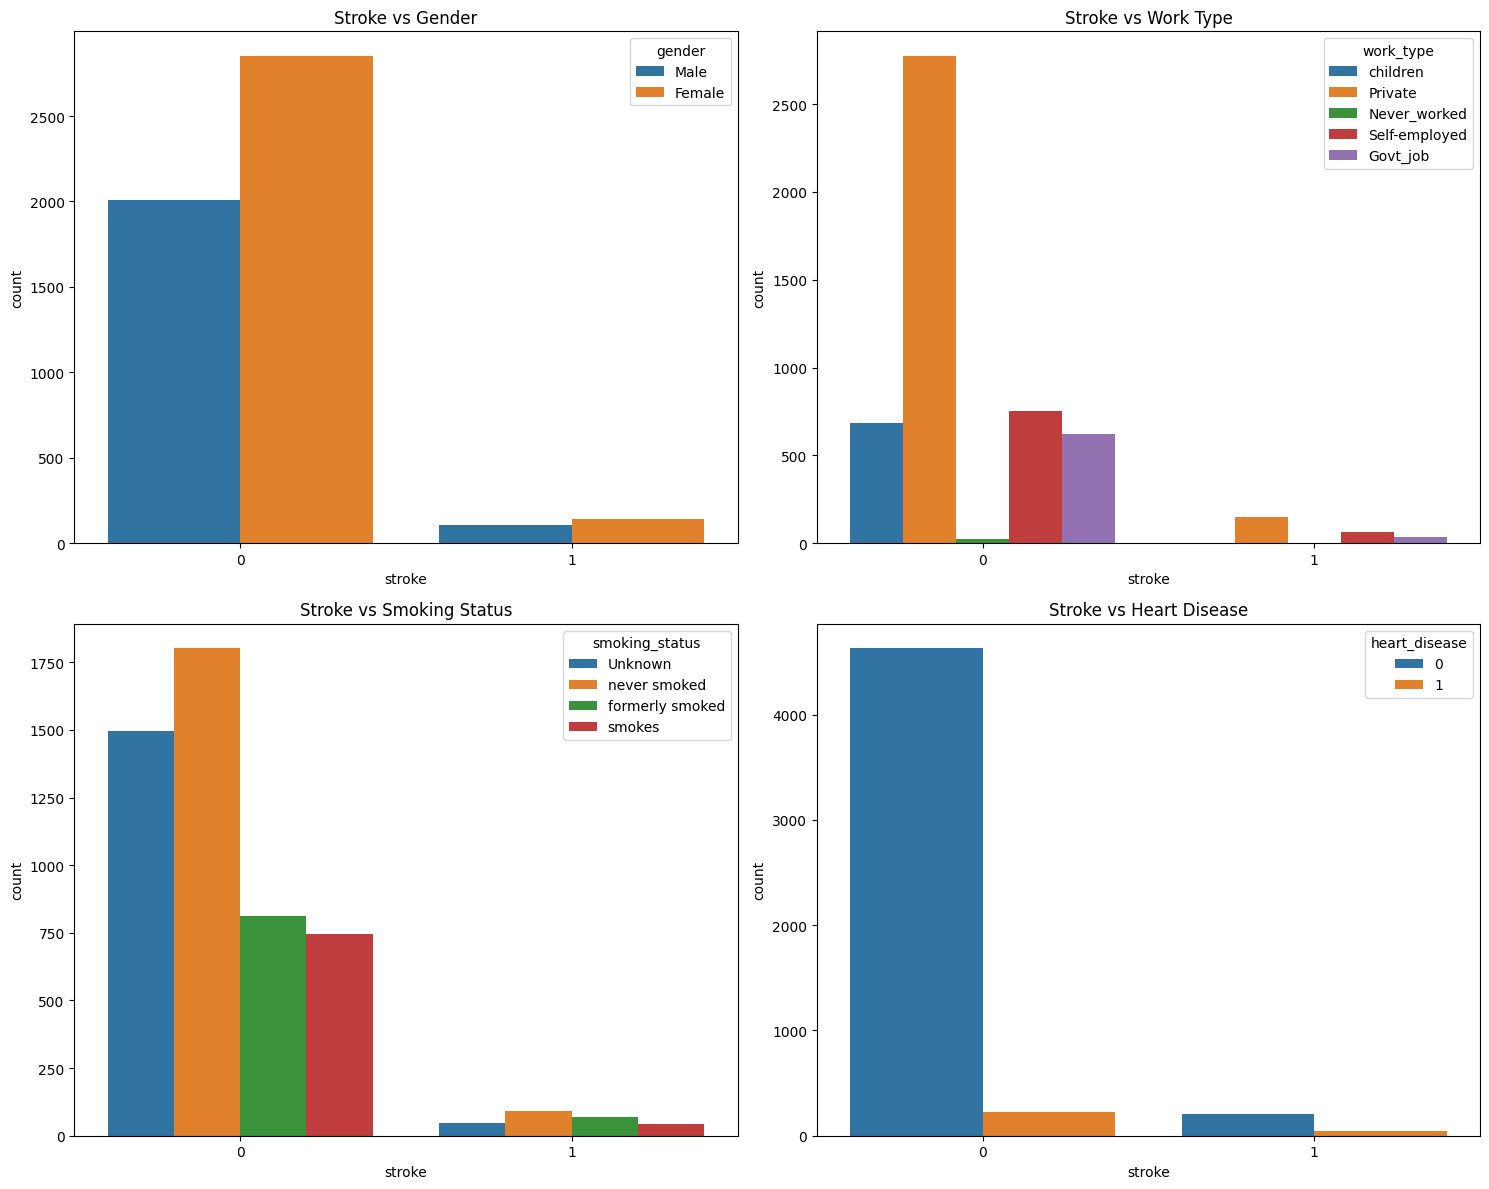

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Stroke vs Gender
sns.countplot(x='stroke', hue='gender', data=df, ax=axes[0,0])
axes[0,0].set_title('Stroke vs Gender')

# Stroke vs Work Type
sns.countplot(x='stroke', hue='work_type', data=df, ax=axes[0,1])
axes[0,1].set_title('Stroke vs Work Type')

# Stroke vs Smoking Status
sns.countplot(x='stroke', hue='smoking_status', data=df, ax=axes[1,0])
axes[1,0].set_title('Stroke vs Smoking Status')

# Stroke vs Heart Disease
sns.countplot(x='stroke', hue='heart_disease', data=df, ax=axes[1,1])
axes[1,1].set_title('Stroke vs Heart Disease')

plt.tight_layout()
plt.show()

Preprocessing pipeline (Scale BEFORE SMOTE)

In [8]:
df.drop(['id'], axis=1, inplace=True, errors='ignore')

X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train.loc[:, 'bmi'] = imputer.fit_transform(X_train[['bmi']])
X_test.loc[:, 'bmi'] = imputer.transform(X_test[['bmi']])
joblib.dump(imputer, '../model/imputer.pkl')

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()
num_features = ['age', 'avg_glucose_level', 'bmi']
X_train.loc[:, num_features] = scaler.fit_transform(X_train[num_features])
X_test.loc[:, num_features] = scaler.transform(X_test[num_features])
joblib.dump(scaler, '../model/scaler.pkl')

print("Preprocessing & Scaling completed.")

Preprocessing & Scaling completed.


SMOTE & balance visualization

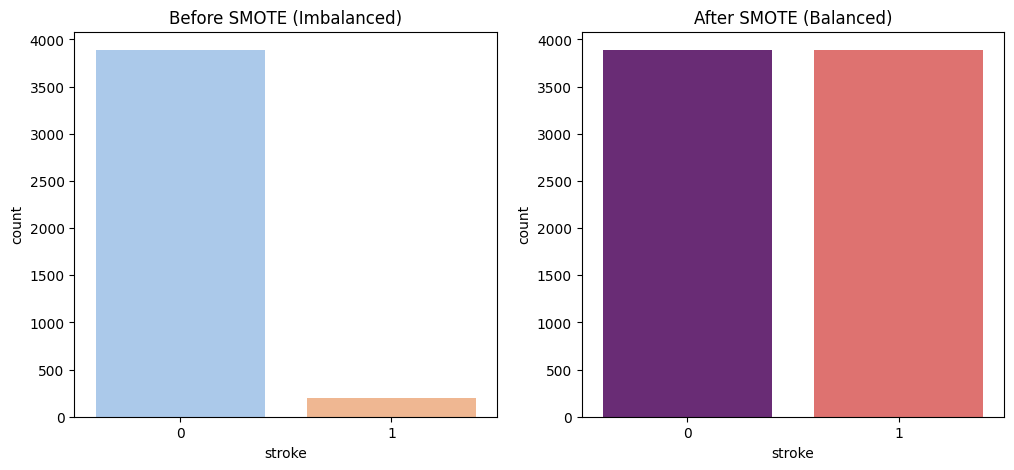

In [9]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=ax[0], palette='pastel')
ax[0].set_title('Before SMOTE (Imbalanced)')
sns.countplot(x=y_train_res, ax=ax[1], palette='magma')
ax[1].set_title('After SMOTE (Balanced)')
plt.show()

Feature importance & export

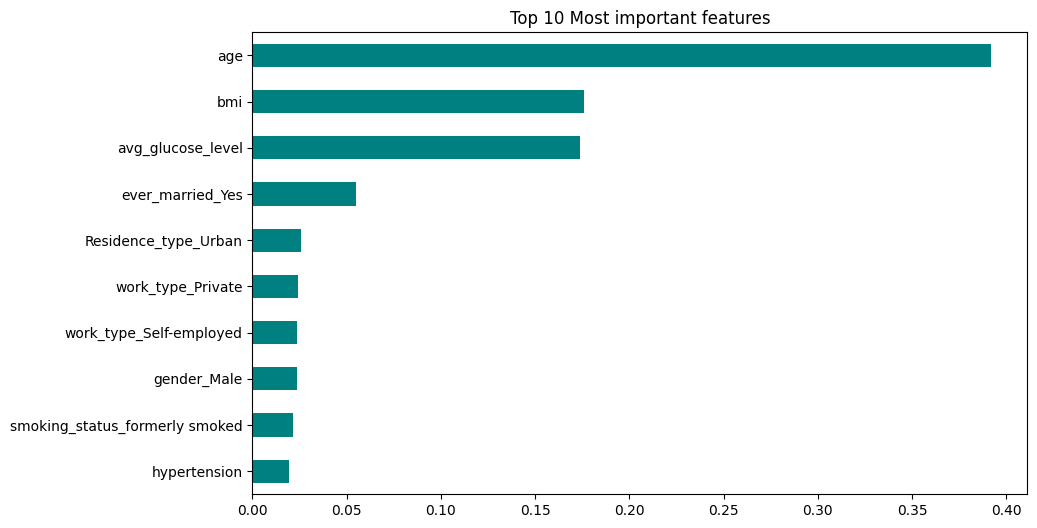

PROCESS COMPLETED: Files saved in ../data/processed/


In [11]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X_train_res.columns)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Top 10 Most important features")
plt.show()

train_final = X_train_res.copy()
train_final['stroke'] = y_train_res
train_final.to_csv('../data/processed/train_final.csv', index=False)

test_final = X_test.copy()
test_final['stroke'] = y_test.values
test_final.to_csv('../data/processed/test_final.csv', index=False)

print("PROCESS COMPLETED: Files saved in ../data/processed/")

Logistic Regression

In [12]:
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             roc_auc_score, roc_curve, precision_score, recall_score, f1_score)

os.makedirs('../model', exist_ok=True)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_res, y_train_res)

features = X_train_res.columns.tolist()
joblib.dump(features, '../model/features.pkl')

print("Logistic Regression model trained successfully and feature list saved!")

Logistic Regression model trained successfully and feature list saved!


In [15]:
y_prob = lr_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

joblib.dump(custom_threshold, '../model/threshold.pkl')

def evaluate_summary(y_true, y_pred, title):
    print(f"\n{'='*10} {title} {'='*10}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f} ")
    print(f"F1-score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

evaluate_summary(y_test, y_pred_custom, f"RESULTS WITH CUSTOM THRESHOLD ({custom_threshold})")


========== RESULTS WITH CUSTOM THRESHOLD (0.3) ==========
Accuracy:  0.6438
Precision: 0.1035
Recall:    0.8200 
F1-score:  0.1839

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.63      0.77       972
           1       0.10      0.82      0.18        50

    accuracy                           0.64      1022
   macro avg       0.54      0.73      0.48      1022
weighted avg       0.94      0.64      0.74      1022



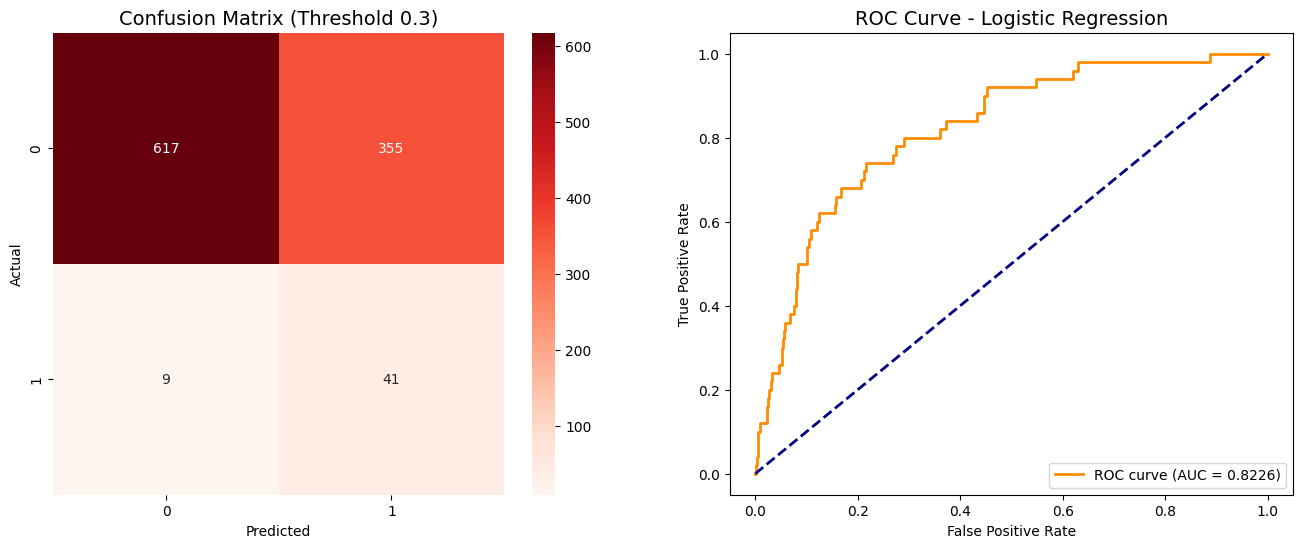

Detailed Confusion Matrix:
[[617 355]
 [  9  41]]


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title(f'Confusion Matrix (Threshold {custom_threshold})', fontsize=14)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

auc_score = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('ROC Curve - Logistic Regression', fontsize=14)
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc="lower right")

plt.show()

print("Detailed Confusion Matrix:")
print(cm_custom)

In [17]:
joblib.dump(lr_model, '../model/logistic_regression_model.pkl')

['../model/logistic_regression_model.pkl']